# RAG Hypothesis Evaluation Results\nVisualizing accuracy, cost, and performance across hypothesis experiments.

In [101]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

df = pd.read_csv("results.csv")

# Filter to runs that completed successfully
valid = df[df["finqa_ok"] == "yes"].copy()

# Short labels for x-axis
valid["label"] = valid["hypothesis_name"].str.replace("_", "\n", regex=False)

# Extract decision from notes
valid["decision"] = valid["notes"].fillna("").str.extract(r"final judge decision=(\w+)")

# Color by decision
colors = valid["decision"].map({"promoted": "#2ecc71", "rejected": "#e74c3c"}).fillna("#95a5a6")

print(f"Total rows: {len(df)}, Valid (finqa_ok=yes): {len(valid)}")
valid[["hypothesis_name", "finqa_accuracy", "finqa_total_cost_usd", "decision"]].to_string()

Total rows: 55, Valid (finqa_ok=yes): 45


'                                 hypothesis_name  finqa_accuracy  finqa_total_cost_usd  decision\n0                               baseline_develop          0.8333              0.058086       NaN\n1                         h01_hybrid_vector_text          0.8667              0.056340       NaN\n2            h02_document_diversified_topk_rerun          0.8333              0.040700       NaN\n3             h02_document_diversified_topk_live          0.8333              0.067119       NaN\n4           h03_table_preserving_finqa_ingestion          0.8000              0.069845       NaN\n5           h04_structure_aware_chunk_boundaries          0.8333              0.050251       NaN\n6                 h05_adaptive_numeric_retrieval          0.8000              0.062566       NaN\n7                   h06_neighbor_chunk_expansion          0.8333              0.046666       NaN\n8                  h07_context_packing_and_dedup          0.8333              0.047295       NaN\n9                 h

## FinQA Accuracy by Hypothesis\nGreen = promoted, Red = rejected. Dashed line = baseline accuracy.

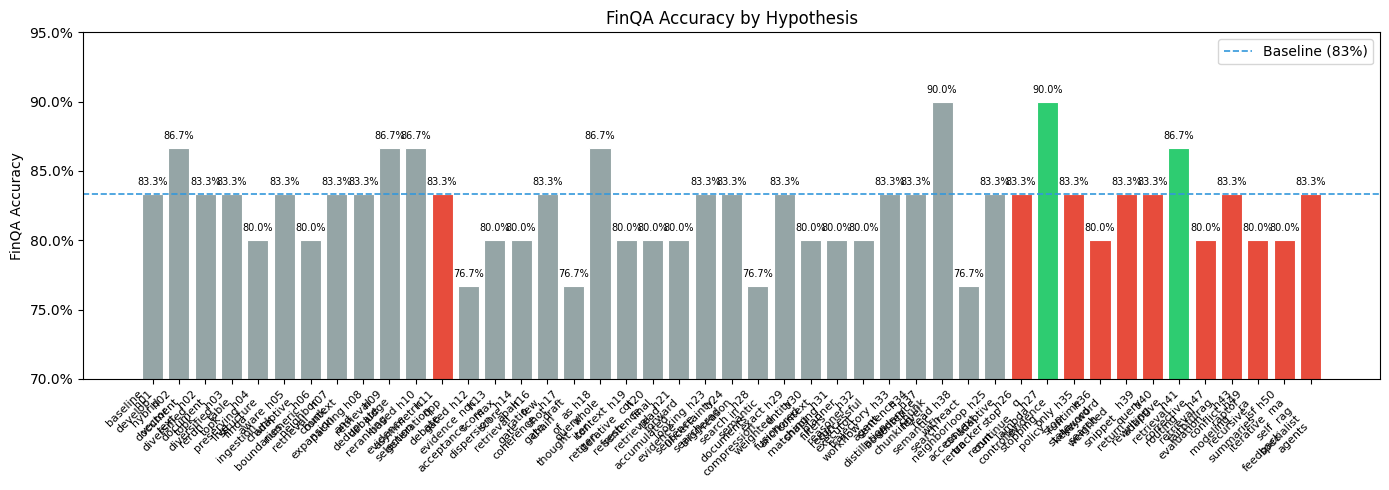

In [102]:
fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(valid))
bars = ax.bar(x, valid["finqa_accuracy"], color=colors, edgecolor="white", linewidth=0.8)

# Baseline reference line
baseline_acc = valid.loc[valid["hypothesis_name"] == "baseline_develop", "finqa_accuracy"].values[0]
ax.axhline(baseline_acc, color="#3498db", linestyle="--", linewidth=1.2, label=f"Baseline ({baseline_acc:.0%})")

ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=8)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylabel("FinQA Accuracy")
ax.set_title("FinQA Accuracy by Hypothesis")
ax.set_ylim(0.7, 0.95)
ax.legend()

for i, v in enumerate(valid["finqa_accuracy"]):
    ax.text(i, v + 0.005, f"{v:.1%}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## FinQA vs HotpotQA Accuracy\nSide-by-side comparison across all hypotheses. Missing evaluations shown as gaps. HotpotQA shows Answer EM, Answer F1, and Joint F1.

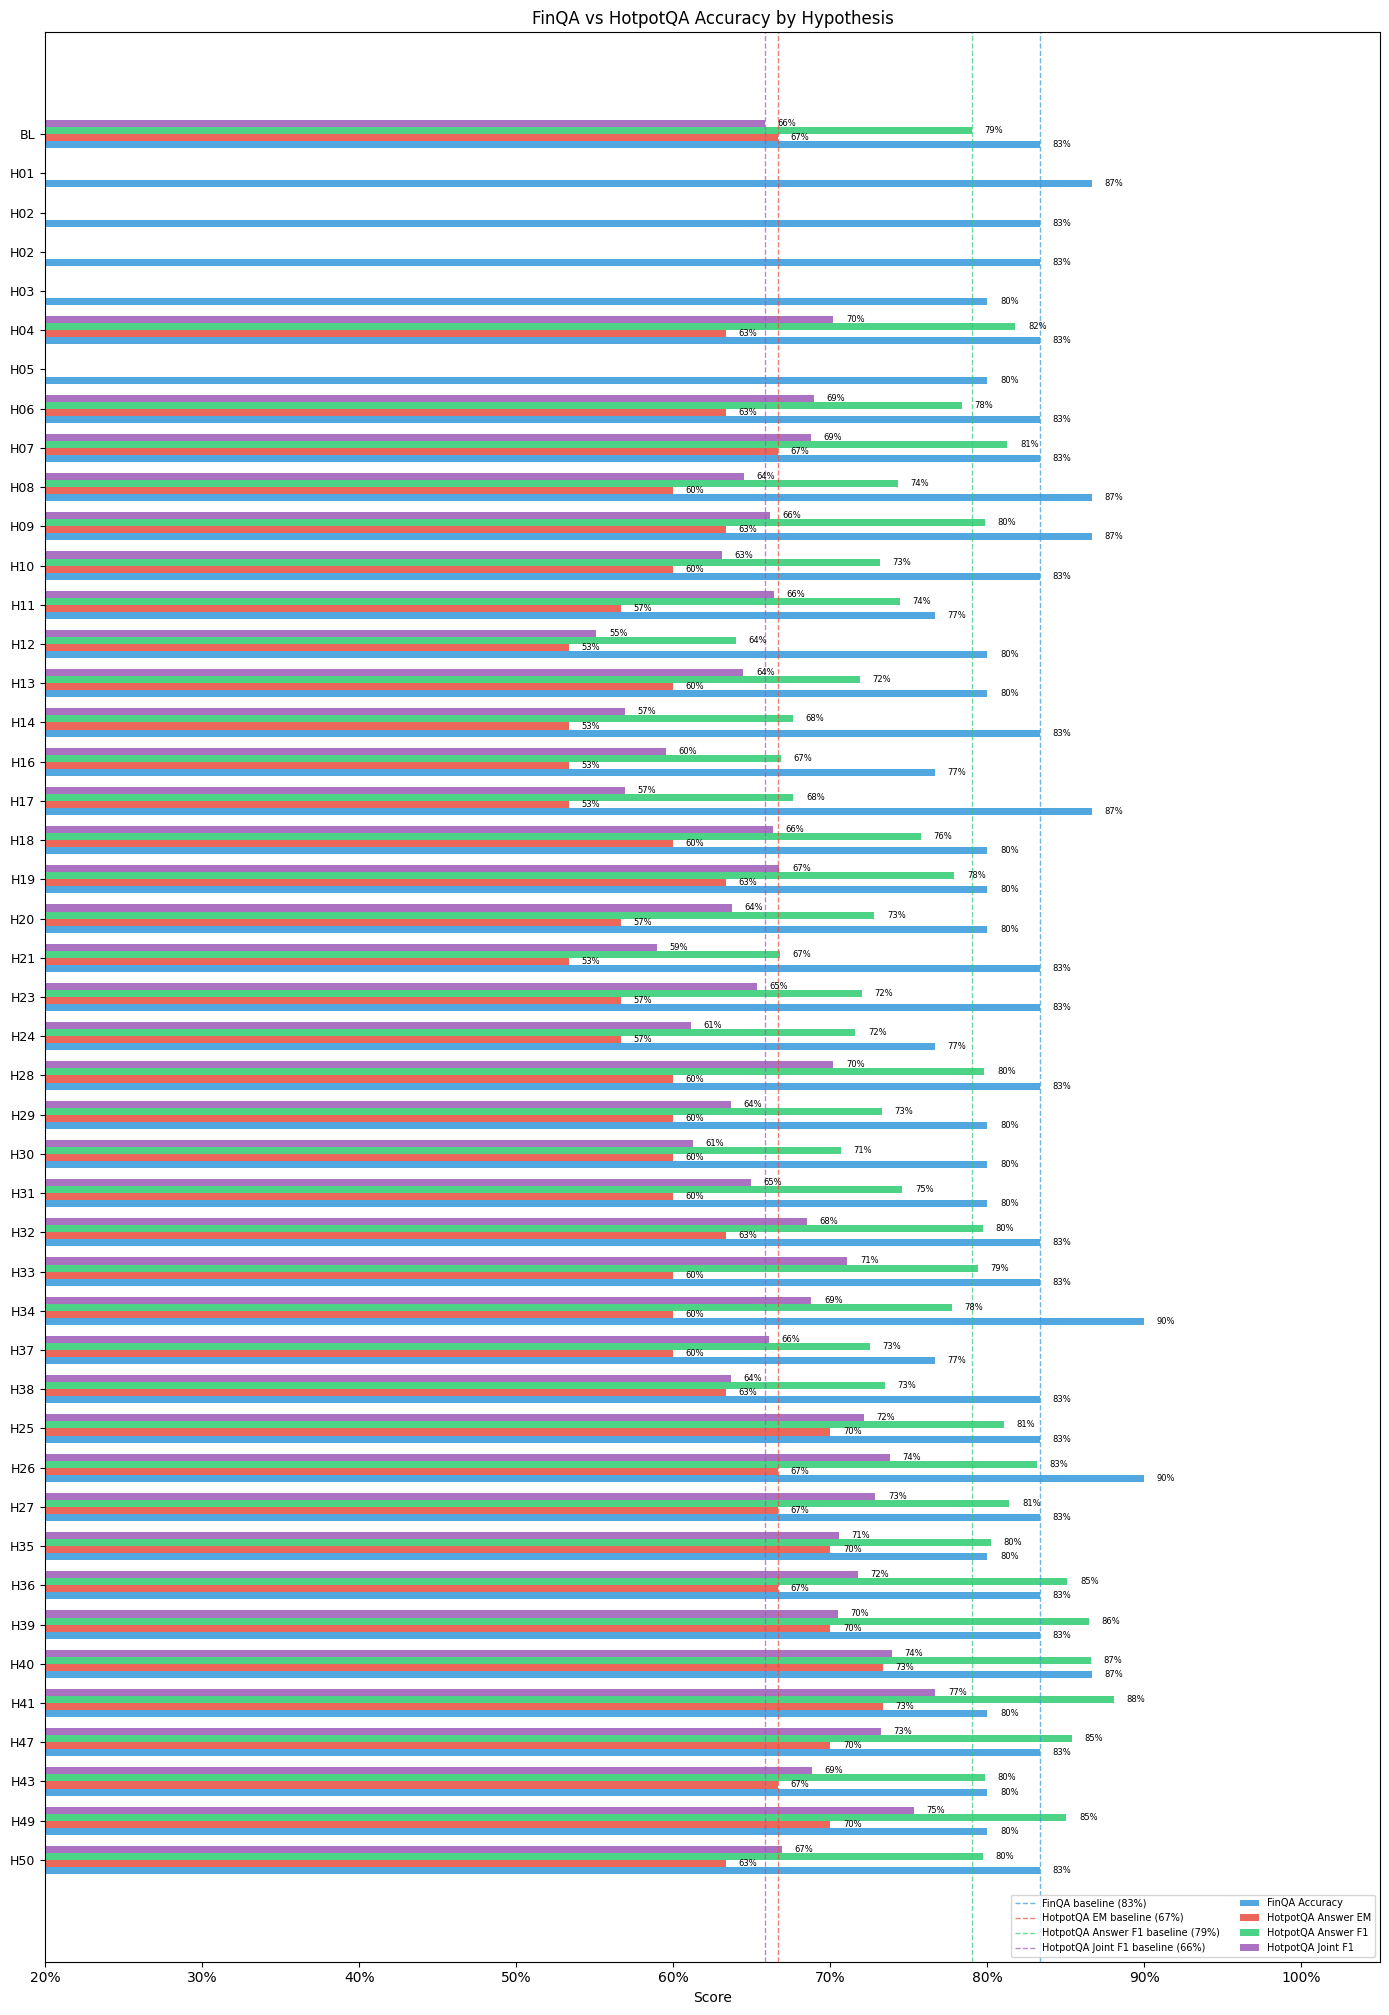

In [103]:
# Build short H## labels; baselines get "BL" / "BL-ri"
def short_label(name):
    import re
    m = re.match(r"h(\d+)", name)
    if m:
        return f"H{m.group(1).zfill(2)}"
    if name == "baseline_develop":
        return "BL"
    if name == "baseline_reindexed_develop":
        return "BL-ri"
    return name[:8]

valid["short"] = valid["hypothesis_name"].apply(short_label)

# Baselines for dashed lines
bl_row = valid.loc[valid["hypothesis_name"] == "baseline_reindexed_develop"]
if len(bl_row) == 0:
    bl_row = valid.iloc[[0]]
finqa_bl = bl_row["finqa_accuracy"].values[0]
hotpot_em_bl = bl_row["hotpot_answer_em"].values[0] if pd.notna(bl_row["hotpot_answer_em"].values[0]) else None
hotpot_af1_bl = bl_row["hotpot_answer_f1"].values[0] if pd.notna(bl_row["hotpot_answer_f1"].values[0]) else None
hotpot_jf1_bl = bl_row["hotpot_joint_f1"].values[0] if pd.notna(bl_row["hotpot_joint_f1"].values[0]) else None

fig, ax = plt.subplots(figsize=(14, max(5, len(valid) * 0.45)))
y = np.arange(len(valid))
width = 0.18

# Distinct colors for each metric
c_finqa = "#3498db"
c_hotpot_em = "#e74c3c"
c_hotpot_af1 = "#2ecc71"
c_hotpot_jf1 = "#9b59b6"

# Horizontal bars
ax.barh(y + 1.5 * width, valid["finqa_accuracy"], width, label="FinQA Accuracy", color=c_finqa, alpha=0.85)
ax.barh(y + 0.5 * width, valid["hotpot_answer_em"], width, label="HotpotQA Answer EM", color=c_hotpot_em, alpha=0.85)
ax.barh(y - 0.5 * width, valid["hotpot_answer_f1"], width, label="HotpotQA Answer F1", color=c_hotpot_af1, alpha=0.85)
ax.barh(y - 1.5 * width, valid["hotpot_joint_f1"], width, label="HotpotQA Joint F1", color=c_hotpot_jf1, alpha=0.85)

# Baseline vertical dashed lines for all 4 metrics
ax.axvline(finqa_bl, color=c_finqa, linestyle="--", linewidth=1, alpha=0.7, label=f"FinQA baseline ({finqa_bl:.0%})")
if hotpot_em_bl is not None:
    ax.axvline(hotpot_em_bl, color=c_hotpot_em, linestyle="--", linewidth=1, alpha=0.7, label=f"HotpotQA EM baseline ({hotpot_em_bl:.0%})")
if hotpot_af1_bl is not None:
    ax.axvline(hotpot_af1_bl, color=c_hotpot_af1, linestyle="--", linewidth=1, alpha=0.7, label=f"HotpotQA Answer F1 baseline ({hotpot_af1_bl:.0%})")
if hotpot_jf1_bl is not None:
    ax.axvline(hotpot_jf1_bl, color=c_hotpot_jf1, linestyle="--", linewidth=1, alpha=0.7, label=f"HotpotQA Joint F1 baseline ({hotpot_jf1_bl:.0%})")

# Value labels
for i, v in enumerate(valid["finqa_accuracy"]):
    ax.text(v + 0.008, i + 1.5 * width, f"{v:.0%}", ha="left", va="center", fontsize=6)
for col, offset in [("hotpot_answer_em", 0.5), ("hotpot_answer_f1", -0.5), ("hotpot_joint_f1", -1.5)]:
    for i, v in enumerate(valid[col]):
        if pd.notna(v):
            ax.text(v + 0.008, i + offset * width, f"{v:.0%}", ha="left", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(valid["short"], fontsize=9)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel("Score")
ax.set_title("FinQA vs HotpotQA Accuracy by Hypothesis")
ax.set_xlim(0.2, 1.05)
ax.legend(loc="lower right", fontsize=7, ncol=2)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Cost vs Accuracy Tradeoff\nBubble size = wall clock time. Ideal hypotheses are in the top-left (high accuracy, low cost).

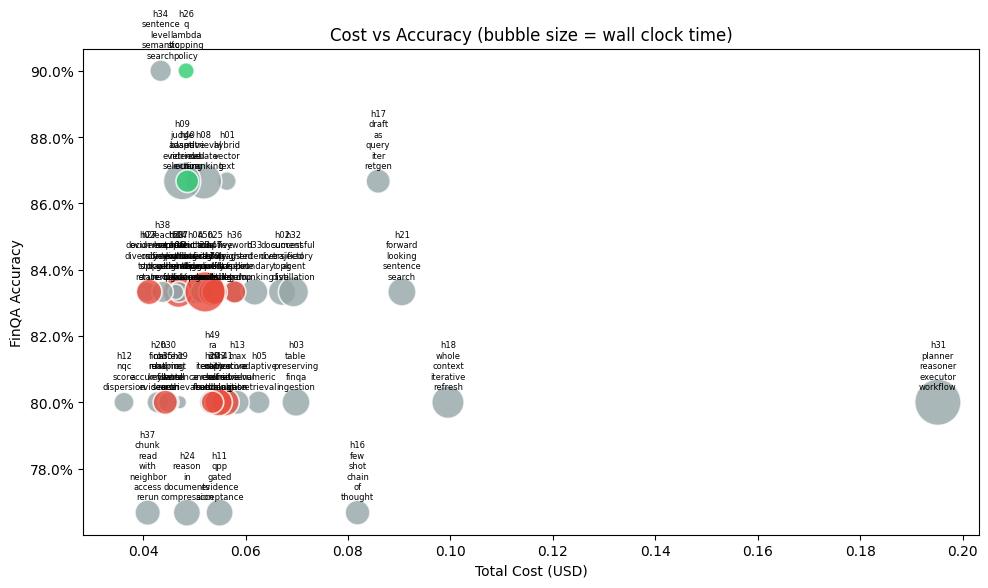

In [104]:
fig, ax = plt.subplots(figsize=(10, 6))

sizes = valid["finqa_wall_clock_s"] * 3  # scale for visibility
scatter = ax.scatter(
    valid["finqa_total_cost_usd"], valid["finqa_accuracy"],
    s=sizes, c=colors, alpha=0.8, edgecolors="white", linewidth=1.2
)

for _, row in valid.iterrows():
    ax.annotate(
        row["hypothesis_name"].replace("_", "\n"),
        (row["finqa_total_cost_usd"], row["finqa_accuracy"]),
        fontsize=6, ha="center", va="bottom",
        xytext=(0, 8), textcoords="offset points"
    )

ax.set_xlabel("Total Cost (USD)")
ax.set_ylabel("FinQA Accuracy")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("Cost vs Accuracy (bubble size = wall clock time)")
plt.tight_layout()
plt.show()

## HotpotQA Results (where available)\nComparing answer EM, answer F1, and joint F1 across hypotheses that ran HotpotQA.

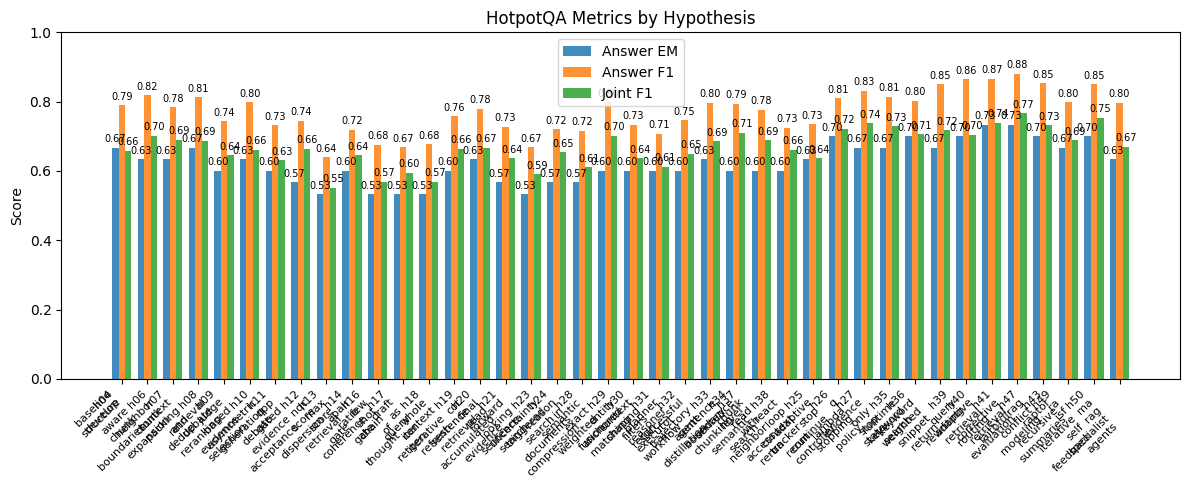

In [105]:
hotpot = valid[valid["hotpot_ok"] == "yes"].copy()

if len(hotpot) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    
    metrics = ["hotpot_answer_em", "hotpot_answer_f1", "hotpot_joint_f1"]
    metric_labels = ["Answer EM", "Answer F1", "Joint F1"]
    x = np.arange(len(hotpot))
    width = 0.25
    
    for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
        bars = ax.bar(x + i * width, hotpot[metric], width, label=label, alpha=0.85)
        for j, v in enumerate(hotpot[metric]):
            ax.text(x[j] + i * width, v + 0.01, f"{v:.2f}", ha="center", va="bottom", fontsize=7)
    
    ax.set_xticks(x + width)
    labels = hotpot["hypothesis_name"].str.replace("_", "\n")
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Score")
    ax.set_title("HotpotQA Metrics by Hypothesis")
    ax.set_ylim(0, 1.0)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No HotpotQA results available.")

## Token Usage & Cost Breakdown

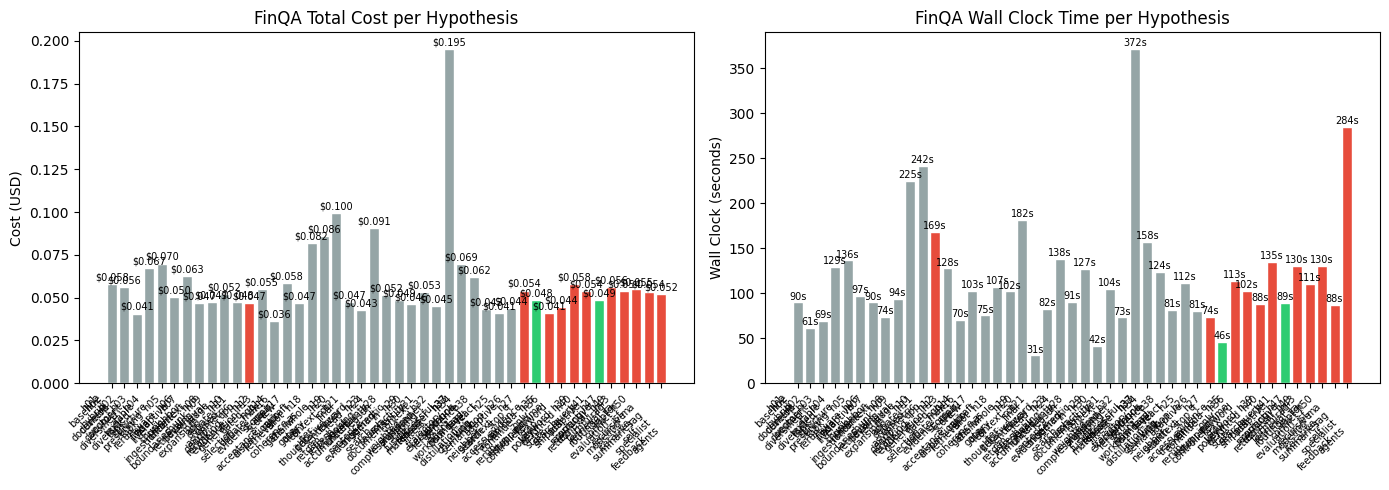

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Cost comparison
ax = axes[0]
x = range(len(valid))
ax.bar(x, valid["finqa_total_cost_usd"], color=colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Cost (USD)")
ax.set_title("FinQA Total Cost per Hypothesis")
for i, v in enumerate(valid["finqa_total_cost_usd"]):
    ax.text(i, v + 0.001, f"${v:.3f}", ha="center", va="bottom", fontsize=7)

# Wall clock time
ax = axes[1]
ax.bar(x, valid["finqa_wall_clock_s"], color=colors, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Wall Clock (seconds)")
ax.set_title("FinQA Wall Clock Time per Hypothesis")
for i, v in enumerate(valid["finqa_wall_clock_s"]):
    ax.text(i, v + 1, f"{v:.0f}s", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

## Token Composition (Input vs Cached vs Output)

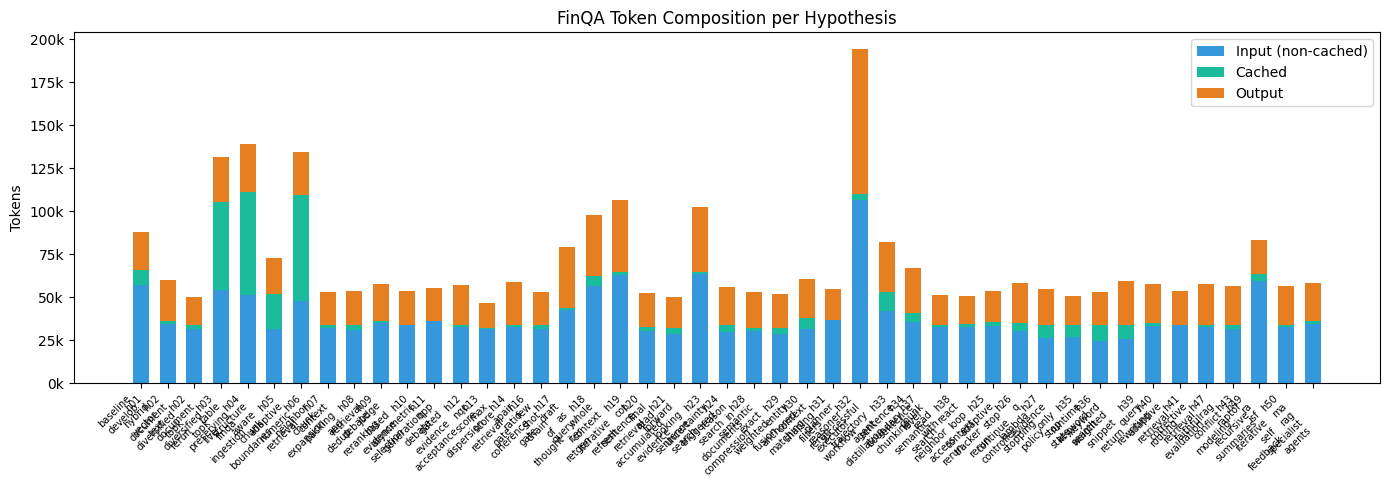

In [107]:
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(valid))
width = 0.6

# Stacked bar: input (non-cached), cached, output
non_cached_input = valid["finqa_input_tokens"] - valid["finqa_cached_tokens"]
ax.bar(x, non_cached_input, width, label="Input (non-cached)", color="#3498db")
ax.bar(x, valid["finqa_cached_tokens"], width, bottom=non_cached_input, label="Cached", color="#1abc9c")
ax.bar(x, valid["finqa_output_tokens"], width, bottom=valid["finqa_input_tokens"], label="Output", color="#e67e22")

ax.set_xticks(x)
ax.set_xticklabels(valid["label"], rotation=45, ha="right", fontsize=7)
ax.set_ylabel("Tokens")
ax.set_title("FinQA Token Composition per Hypothesis")
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))

plt.tight_layout()
plt.show()

## Summary: Promoted vs Rejected Hypotheses

In [108]:
summary = valid.groupby("decision").agg(
    count=("hypothesis_name", "count"),
    avg_finqa_accuracy=("finqa_accuracy", "mean"),
    avg_finqa_cost=("finqa_total_cost_usd", "mean"),
    avg_wall_clock_s=("finqa_wall_clock_s", "mean"),
).round(4)

print(summary.to_string())
print(f"\nPromotion rate: {(valid['decision'] == 'promoted').sum()}/{len(valid)} = {(valid['decision'] == 'promoted').mean():.0%}")

          count  avg_finqa_accuracy  avg_finqa_cost  avg_wall_clock_s
decision                                                             
promoted      2              0.8834          0.0485           67.7500
rejected     11              0.8212          0.0517          129.4909

Promotion rate: 2/45 = 4%
